In [1]:
!pip install yfinance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 11.8 MB/s  0:00:00 48.0 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11/11 [yfinance] 10/11 [yfinance]otobuf]s]


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime

# 1. Data Collection

In [6]:
now = datetime.now()


start = datetime(now.year-10, now.month, now.day)
end = now
ticker = 'AAPL'

# importing data from yahoo finance
df = yf.download(ticker, start, end)   # ticker - Symbol , start - previous stock data , end - now

df

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2016-04-27,22.154316,22.355883,21.669648,21.742122,458408400
2016-04-28,21.477142,22.167907,21.345783,22.106758,328970800
2016-04-29,21.230276,21.452228,20.951706,21.286896,274126000
2016-05-02,21.207634,21.307286,20.926799,21.282373,192640400
2016-05-03,21.556416,21.683244,21.216695,21.334464,227325200
...,...,...,...,...,...
2026-04-20,273.049988,274.279999,270.290009,270.329987,36590200
2026-04-21,266.170013,272.799988,265.399994,271.500000,50209800


In [7]:
df.head()    # first 5 records

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2016-04-27,22.154316,22.355883,21.669648,21.742122,458408400
2016-04-28,21.477142,22.167907,21.345783,22.106758,328970800
2016-04-29,21.230276,21.452228,20.951706,21.286896,274126000
2016-05-02,21.207634,21.307286,20.926799,21.282373,192640400
2016-05-03,21.556416,21.683244,21.216695,21.334464,227325200


In [8]:
df.tail()  # last 5 records

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2026-04-20,273.049988,274.279999,270.290009,270.329987,36590200
2026-04-21,266.170013,272.799988,265.399994,271.500000,50209800
2026-04-22,273.170013,273.739990,266.869995,267.820007,43249200
2026-04-23,273.429993,275.769989,271.649994,275.049988,33399600
2026-04-24,271.059998,273.059998,269.649994,272.760010,38124500


# 2. Data Exploration & Visualization

In [9]:
df

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2016-04-27,22.154316,22.355883,21.669648,21.742122,458408400
2016-04-28,21.477142,22.167907,21.345783,22.106758,328970800
2016-04-29,21.230276,21.452228,20.951706,21.286896,274126000
2016-05-02,21.207634,21.307286,20.926799,21.282373,192640400
2016-05-03,21.556416,21.683244,21.216695,21.334464,227325200
...,...,...,...,...,...
2026-04-20,273.049988,274.279999,270.290009,270.329987,36590200
2026-04-21,266.170013,272.799988,265.399994,271.500000,50209800


In [10]:
type(df)

pandas.DataFrame

In [11]:
df.shape

(2513, 5)

In [13]:
df.isna().sum   # check any NULL values

<bound method DataFrame.sum of Price       Close   High    Low   Open Volume
Ticker       AAPL   AAPL   AAPL   AAPL   AAPL
Date                                         
2016-04-27  False  False  False  False  False
2016-04-28  False  False  False  False  False
2016-04-29  False  False  False  False  False
2016-05-02  False  False  False  False  False
2016-05-03  False  False  False  False  False
...           ...    ...    ...    ...    ...
2026-04-20  False  False  False  False  False
2026-04-21  False  False  False  False  False
2026-04-22  False  False  False  False  False
2026-04-23  False  False  False  False  False
2026-04-24  False  False  False  False  False

[2513 rows x 5 columns]>

In [14]:
df.dropna(inplace=True)  # if any null values then delete it

In [15]:
df.isna().sum

<bound method DataFrame.sum of Price       Close   High    Low   Open Volume
Ticker       AAPL   AAPL   AAPL   AAPL   AAPL
Date                                         
2016-04-27  False  False  False  False  False
2016-04-28  False  False  False  False  False
2016-04-29  False  False  False  False  False
2016-05-02  False  False  False  False  False
2016-05-03  False  False  False  False  False
...           ...    ...    ...    ...    ...
2026-04-20  False  False  False  False  False
2026-04-21  False  False  False  False  False
2026-04-22  False  False  False  False  False
2026-04-23  False  False  False  False  False
2026-04-24  False  False  False  False  False

[2513 rows x 5 columns]>

In [17]:
df.describe()   # Satastical overview of the dataframe

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,2513.000000,2513.000000,2513.000000,2513.000000,2.513000e+03
mean,121.604292,122.816736,120.278112,121.499303,9.779405e+07
std,75.670218,76.402793,74.876572,75.616668,5.590263e+07
min,20.584816,20.887866,20.386579,20.507342,1.791060e+07
25%,44.379009,44.697376,44.058867,44.336552,5.846910e+07
50%,127.574211,128.961953,126.097865,127.663821,8.597280e+07
75%,177.282303,178.869344,175.275708,177.368975,1.186556e+08
max,285.922455,288.350192,283.035157,285.932471,4.584084e+08


In [19]:
df.dtypes

Price   Ticker
Close   AAPL      float64
High    AAPL      float64
Low     AAPL      float64
Open    AAPL      float64
Volume  AAPL        int64
dtype: object

In [20]:
df.head()    # the date is index

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2016-04-27,22.154316,22.355883,21.669648,21.742122,458408400
2016-04-28,21.477142,22.167907,21.345783,22.106758,328970800
2016-04-29,21.230276,21.452228,20.951706,21.286896,274126000
2016-05-02,21.207634,21.307286,20.926799,21.282373,192640400
2016-05-03,21.556416,21.683244,21.216695,21.334464,227325200


In [21]:
# reset index 
df = df.reset_index()

In [23]:
df.head()  # index changed

Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
0,2016-04-27,22.154316,22.355883,21.669648,21.742122,458408400
1,2016-04-28,21.477142,22.167907,21.345783,22.106758,328970800
2,2016-04-29,21.230276,21.452228,20.951706,21.286896,274126000
3,2016-05-02,21.207634,21.307286,20.926799,21.282373,192640400
4,2016-05-03,21.556416,21.683244,21.216695,21.334464,227325200


Text(0, 0.5, 'Close price')

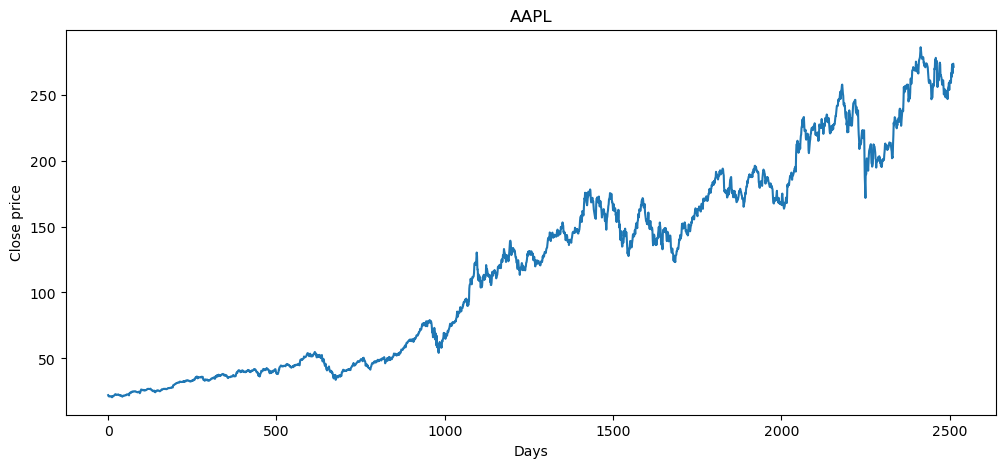

In [26]:
plt.figure(figsize=(12, 5))
plt.plot(df.Close)

plt.title(ticker)
plt.xlabel('Days')
plt.ylabel('Close price')

# 3. Feature Engineering

In [32]:
# Moving Average of 5 days

# 10, 20, 30, 40, 50, 60, 70, 80, 90, 100
# MA of 5 days ==> null, null, null, null, 30 , 40
#  30 = (10+20+30+40+50)/5

temp_df = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
print(sum(temp_df[1:6])/5)
print(sum(temp_df[2:7])/5)
print(sum(temp_df[3:8])/5)
print(sum(temp_df[4:9])/5)

40.0
50.0
60.0
70.0


In [58]:


df1 = pd.DataFrame([10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
df1

,0
0,10
1,20
2,30
3,40
4,50
5,60
6,70
7,80
8,90
9,100


In [59]:
df1['MA_5'] = df1.rolling(5).mean()

In [60]:
df1

,0,MA_5
0,10,NaN
1,20,NaN
2,30,NaN
3,40,NaN
4,50,30.0
5,60,40.0
6,70,50.0
7,80,60.0
8,90,70.0
9,100,80.0


In [49]:
# Sample stock data
data = {
    'Date':   ['2024-01-01','2024-01-02','2024-01-03','2024-01-04','2024-01-05',
               '2024-01-06','2024-01-07','2024-01-08','2024-01-09','2024-01-10'],
    'Close':  [100, 105, 102, 108, 111, 107, 115, 120, 118, 125]
}

df2 = pd.DataFrame(data)
df2['Date'] = pd.to_datetime(df2['Date'])
df2.set_index('Date', inplace=True)

print(df1)

            Close
Date             
2024-01-01    100
2024-01-02    105
2024-01-03    102
2024-01-04    108
2024-01-05    111
2024-01-06    107
2024-01-07    115
2024-01-08    120
2024-01-09    118
2024-01-10    125


In [63]:
# ── Sample Stock Data ──────────────────────────────────────
data = {
    'Date': ['2024-01-01','2024-01-02','2024-01-03','2024-01-04','2024-01-05',
             '2024-01-06','2024-01-07','2024-01-08','2024-01-09','2024-01-10',
             '2024-01-11','2024-01-12','2024-01-13','2024-01-14','2024-01-15'],
    'Close': [100, 105, 102, 108, 111, 107, 115, 120, 118, 125,
              122, 130, 128, 135, 140]
}

df3 = pd.DataFrame(data)
df3['Date']  = pd.to_datetime(df3['Date'])   #  Converting Date Column , Before : '2024-01-01' (string)      After : 2024-01-01 (datetime object)
df3.set_index('Date', inplace=True)          # Before : Date is a normal column  , After : Date becomes the row label (index)

# ── Calculate Moving Averages ──────────────────────────────
df3['MA_3']  = df3['Close'].rolling(3).mean()   # 3-day MA
df3['MA_5']  = df3['Close'].rolling(5).mean()   # 5-day MA
df3['MA_7']  = df3['Close'].rolling(7).mean()   # 7-day MA

print(df)

            Close        MA_3   MA_5        MA_7  MA_100
Date                                                    
2024-01-01    100         NaN    NaN         NaN     NaN
2024-01-02    105         NaN    NaN         NaN     NaN
2024-01-03    102  102.333333    NaN         NaN     NaN
2024-01-04    108  105.000000    NaN         NaN     NaN
2024-01-05    111  107.000000  105.2         NaN     NaN
2024-01-06    107  108.666667  106.6         NaN     NaN
2024-01-07    115  111.000000  108.6  106.857143     NaN
2024-01-08    120  114.000000  112.2  109.714286     NaN
2024-01-09    118  117.666667  114.2  111.571429     NaN
2024-01-10    125  121.000000  117.0  114.857143     NaN
2024-01-11    122  121.666667  120.0  116.857143     NaN
2024-01-12    130  125.666667  123.0  119.571429     NaN
2024-01-13    128  126.666667  124.6  122.571429     NaN
2024-01-14    135  131.000000  128.0  125.428571     NaN
2024-01-15    140  134.333333  131.0  128.285714     NaN


## 100 days Moving Average

In [61]:
df['MA_100'] = df.Close.rolling(100).mean()
df.head()

,Close,MA_3,MA_5,MA_7,MA_100
Date,,,,,
2024-01-01,100,NaN,NaN,NaN,NaN
2024-01-02,105,NaN,NaN,NaN,NaN
2024-01-03,102,102.333333,NaN,NaN,NaN
2024-01-04,108,105.000000,NaN,NaN,NaN
2024-01-05,111,107.000000,105.2,NaN,NaN


In [64]:
df

,Close,MA_3,MA_5,MA_7,MA_100
Date,,,,,
2024-01-01,100,NaN,NaN,NaN,NaN
2024-01-02,105,NaN,NaN,NaN,NaN
2024-01-03,102,102.333333,NaN,NaN,NaN
2024-01-04,108,105.000000,NaN,NaN,NaN
2024-01-05,111,107.000000,105.2,NaN,NaN
2024-01-06,107,108.666667,106.6,NaN,NaN
2024-01-07,115,111.000000,108.6,106.857143,NaN
2024-01-08,120,114.000000,112.2,109.714286,NaN
2024-01-09,118,117.666667,114.2,111.571429,NaN


In [4]:
!pip install yfinance

  Using cached yfinance-1.3.0-py2.py3-none-any.whl.metadata (6.1 kB)
  Using cached multitasking-0.0.13-py3-none-any.whl.metadata (16 kB)
  Using cached pytz-2026.1.post1-py2.py3-none-any.whl.metadata (22 kB)
  Using cached frozendict-2.4.7-py3-none-any.whl.metadata (23 kB)
  Using cached peewee-4.0.5-py3-none-any.whl.metadata (8.6 kB)
  Using cached curl_cffi-0.15.0-cp310-abi3-macosx_11_0_arm64.whl.metadata (18 kB)
Using cached yfinance-1.3.0-py2.py3-none-any.whl (133 kB)
Using cached curl_cffi-0.15.0-cp310-abi3-macosx_11_0_arm64.whl (2.6 MB)
Using cached frozendict-2.4.7-py3-none-any.whl (16 kB)
Using cached multitasking-0.0.13-py3-none-any.whl (16 kB)
Using cached peewee-4.0.5-py3-none-any.whl (144 kB)
Using cached pytz-2026.1.post1-py2.py3-none-any.whl (510 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [yfinance]━━━━━━━━━ 4/7 [frozendict]


In [5]:
from datetime import datetime
import yfinance as yf


now = datetime.now()


start = datetime(now.year-10, now.month, now.day)
end = now
ticker = 'AAPL'

# importing data from yahoo finance
df = yf.download(ticker, start, end)   # ticker - Symbol , start - previous stock data , end - now

df

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2016-04-29,21.230276,21.452228,20.951706,21.286896,274126000
2016-05-02,21.207630,21.307282,20.926795,21.282369,192640400
2016-05-03,21.556410,21.683238,21.216689,21.334458,227325200
2016-05-04,21.332195,21.719477,21.248397,21.560939,164102000
2016-05-05,21.245605,21.434729,21.118005,21.418779,143562000
...,...,...,...,...,...
2026-04-22,273.170013,273.739990,266.869995,267.820007,43249200
2026-04-23,273.429993,275.769989,271.649994,275.049988,33399600


In [ ]:
df.head()
